In [1]:
# imports
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import cartopy.crs as ccrs
from esem import gp_model
from eofs.xarray import Eof
from utils import *
import gpflow

2025-03-08 20:01:42.403542: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-08 20:01:42.412341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741489302.421723   74615 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741489302.424708   74615 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-08 20:01:42.436277: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Prepare data

In [2]:
train_files= ['ssp126', 'ssp585', 'historical']

In [3]:
# get data
Xtrain, eof_solvers = get_Xtrain(train_files)
train_nan_mask = Xtrain.isna().any(axis=1).values
Xtrain = Xtrain.dropna(axis=0, how='any')

Ytrain = get_Ytrain(train_files)

Xtest = get_Xtest('ssp370', eof_solvers)
test_nan_mask = Xtest.isna().any(axis=1).values
Xtest = Xtest.dropna(axis=0, how='any')

Ytest = get_Ytest('ssp370')

# Model

In [4]:
crops = ['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh']
models = {}
masks = {}

for crop in crops:
    # Prepare data
    
    # exclude years with missing emission data for training
    Ytrain_yield = Ytrain[crop].values.reshape(-1, 360*720)
    Ytrain_yield = Ytrain_yield[~train_nan_mask]
    assert Xtrain.shape[0]==Ytrain_yield.shape[0]
    
    Ytest_yield = Ytest[crop].values.reshape(-1, 360*720)
    Ytest_yield = Ytest_yield[~test_nan_mask]
    assert Xtest.shape[0]==Ytest_yield.shape[0]

    # use a mask to exclude coordinates with nan yield across all years (these correspond to locations not suitable for growing crops)
    mask_all_nan_by_col = np.isnan(Ytrain_yield).all(axis=0)
    Ytrain_yield_dropped = Ytrain_yield[:, ~mask_all_nan_by_col]
    # then impute the rest with 0
    Y_imputed = np.nan_to_num(Ytrain_yield_dropped, nan=0.0)
    

    
    # Model

    # define kernels
    kernel_CO2 = gpflow.kernels.Matern32(active_dims=[0]) # active_dims specifies which dimension the kernel is applied to
    kernel_CH4 = gpflow.kernels.Matern32(active_dims=[1])
    kernel_BC = gpflow.kernels.Matern32(lengthscales=5 * [1.], active_dims=[2, 3, 4, 5, 6])
    kernel_SO2 = gpflow.kernels.Matern32(lengthscales=5 * [1.], active_dims=[7, 8, 9, 10, 11])
    kernel = kernel_CO2 + kernel_CH4 + kernel_BC + kernel_SO2

    # define model
    np.random.seed(5)
    mean = gpflow.mean_functions.Constant()
    model = gpflow.models.GPR(data=(Xtrain.astype(np.float64), # cast to float64 because gpflow requires numerical stability
                                    Y_imputed.astype(np.float64)),
                              kernel = kernel,
                              mean_function = mean)

    # define optimizer
    optimizer = gpflow.optimizers.Scipy()
    
    # train
    optimizer.minimize(model.training_loss,
                       variables=model.trainable_variables,
                       options=dict(disp=True, maxiter=5000))

    # store the mask
    masks[crop] = mask_all_nan_by_col
    # store the trained model
    models[crop] = model

I0000 00:00:1741489312.682709   74615 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43471 MB memory:  -> device: 0, name: NVIDIA L40, pci bus id: 0000:82:00.0, compute capability: 8.9
I0000 00:00:1741489316.472262   74705 cuda_solvers.cc:178] Creating GpuSolver handles for stream 0x564bca7c98f0


In [5]:
models

{'mai': <gpflow.models.gpr.GPR object at 0x1503dee144f0>
╒════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════╕
│ name                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                              │
╞════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════╡
│ GPR.mean_function.c                │ Parameter │ Identity         │         │ True        │ (1,)    │ float64 │ [2.13518]                          │
├────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────┤
│ GPR.kernel.kernels[0].variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.92425                            │
├────────────────────────────────────

# Predict

In [6]:
predictions = {}
for crop in crops:
    model = models[crop]
    mask_all_nan_by_col = masks[crop]
    
    # predict
    posterior_mean, posterior_var = model.predict_y(Xtest.values) # predicted mean of GP, predicted variance of GP
    posterior_stddev = np.sqrt(posterior_var)
    
    posterior_yield_mean_full = np.full((Xtest.shape[0], Ytrain_yield.shape[1]), np.nan)  # fill with NaN
    posterior_yield_mean_full[:, ~mask_all_nan_by_col] = posterior_mean
    
    posterior_yield_stddev_full = np.full((Xtest.shape[0], Ytrain_yield.shape[1]), np.nan)  # fill with NaN
    posterior_yield_stddev_full[:, ~mask_all_nan_by_col] = posterior_stddev

    # put output back into xarray format for calculating RMSE/plotting
    posterior_yield = np.reshape(posterior_yield_mean_full, [len(Ytest['time']), 360, 720])
    posterior_yield_stddev = np.reshape(posterior_yield_stddev_full, [len(Ytest['time']), 360, 720])
    posterior_yield_data = xr.DataArray(
        posterior_yield,
        dims=("time", "lat", "lon"),
        coords={"time": Ytest["time"], "lat": Ytest["lat"], "lon": Ytest["lon"]}
    )
    posterior_yield_std_data = xr.DataArray(
        posterior_yield_stddev,
        dims=("time", "lat", "lon"),
        coords={"time": Ytest["time"], "lat": Ytest["lat"], "lon": Ytest["lon"]}
    )

    predictions[crop] = {'mean': posterior_yield_data, 'std': posterior_yield_std_data}

# Evaluate Performance

In [7]:
# Compute RMSEs
rmses_all_year = {}

for k,v in predictions.items():
    prediction = v['mean']
    truth = Ytest[k]
    rmses_all_year[k] = []
    
    print(f"RMSE at 2050: {get_rmse(truth[35], prediction[35])}")
    print(f"RMSE at 2100: {get_rmse(truth[85], prediction[85])}")
    print(f"RMSE 2045-2055: {get_rmse(truth[30:41], prediction[30:41]).mean()}")
    print(f"RMSE 2090-2100: {get_rmse(truth[75:], prediction[75:]).mean()}")
    print(f"RMSE 2050-2100: {get_rmse(truth[35:], prediction[35:]).mean()}")
    
    # RMSE for average field over last 20 years
    print(f"RMSE average last 20y: {get_rmse(truth[-20:].mean(dim='time'), prediction[-20:].mean(dim='time'))}")
    print()
    
    for i in range(len(Ytest['time'])):
        rmse = get_rmse(truth[i], prediction[i])
        rmses_all_year[k].append(rmse)

RMSE at 2050: 0.5649584480997286
RMSE at 2100: 0.615129975024253
RMSE 2045-2055: 0.5526300956056932
RMSE 2090-2100: 0.5375820204753743
RMSE 2050-2100: 0.5521728569737571
RMSE average last 20y: 0.16076526248673956

RMSE at 2050: 0.5142879175641607
RMSE at 2100: 0.6223811087893614
RMSE 2045-2055: 0.5135573065830191
RMSE 2090-2100: 0.5475759397471595
RMSE 2050-2100: 0.5459928727143982
RMSE average last 20y: 0.20426330525915243

RMSE at 2050: 0.3886657110903377
RMSE at 2100: 0.4971482769350061
RMSE 2045-2055: 0.3926651894360324
RMSE 2090-2100: 0.43840262796914425
RMSE 2050-2100: 0.42400298808974757
RMSE average last 20y: 0.1357317515924288

RMSE at 2050: 0.834459750168704
RMSE at 2100: 1.066472145450495
RMSE 2045-2055: 0.8716492965056489
RMSE 2090-2100: 0.9444597214498827
RMSE 2050-2100: 0.939537507243699
RMSE average last 20y: 0.28871001546598773

RMSE at 2050: 0.5859943334661424
RMSE at 2100: 0.8105504478636686
RMSE 2045-2055: 0.6073334262835847
RMSE 2090-2100: 0.6844231260707968
RMSE 20

# Plot of predictions

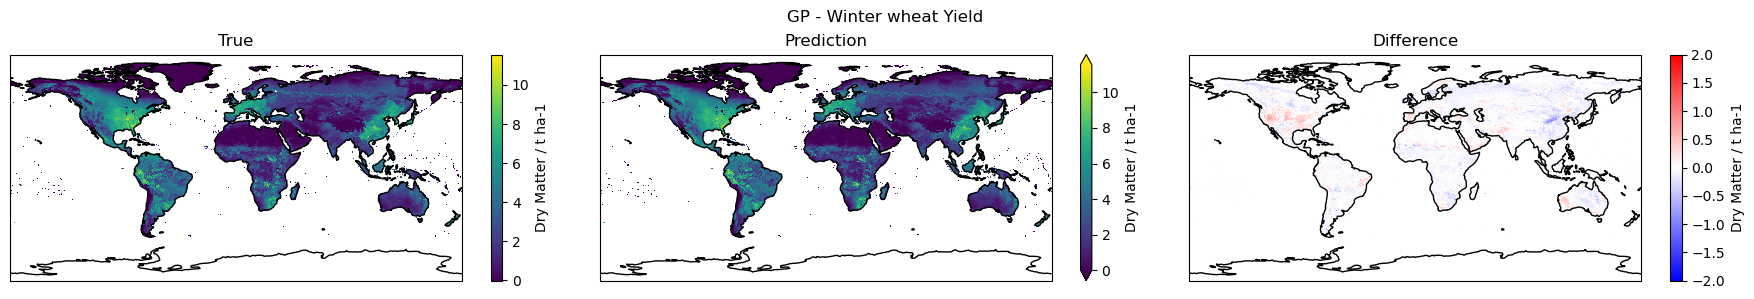

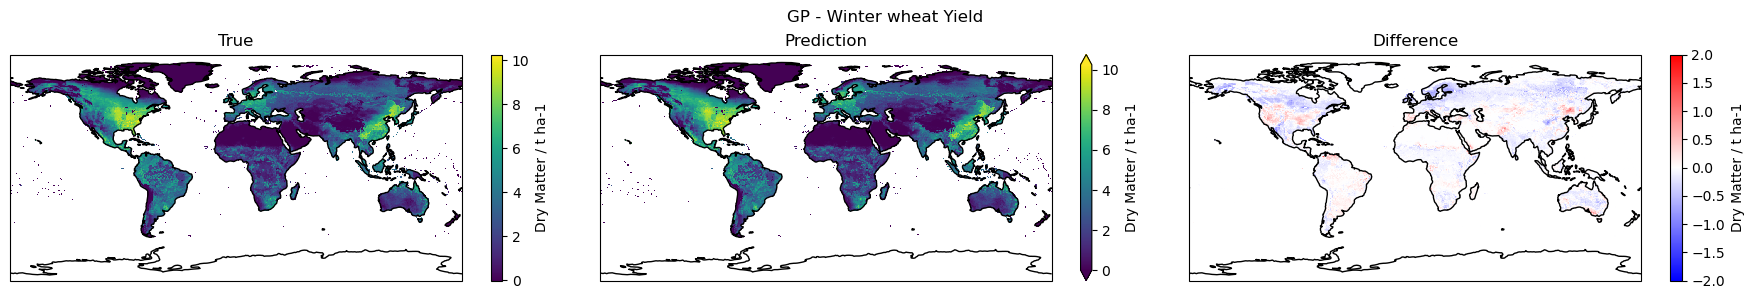

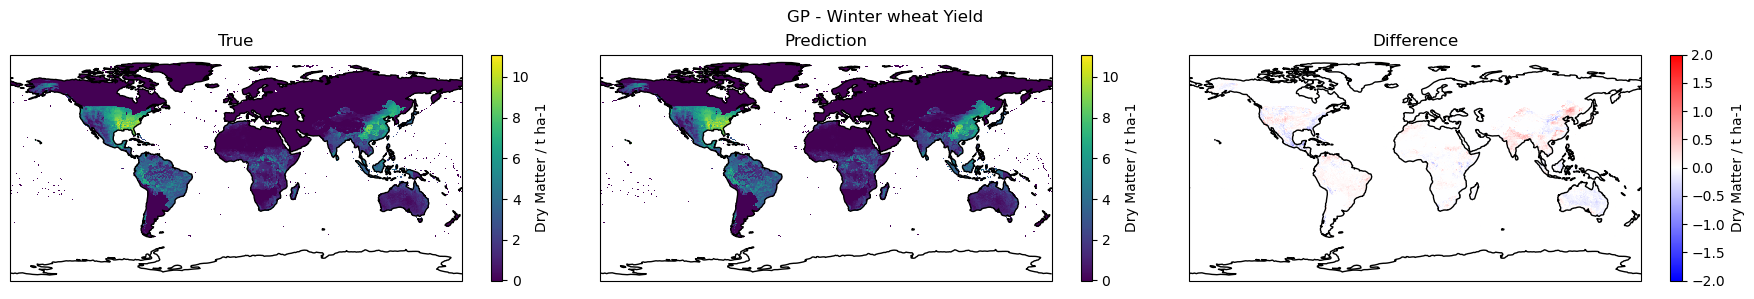

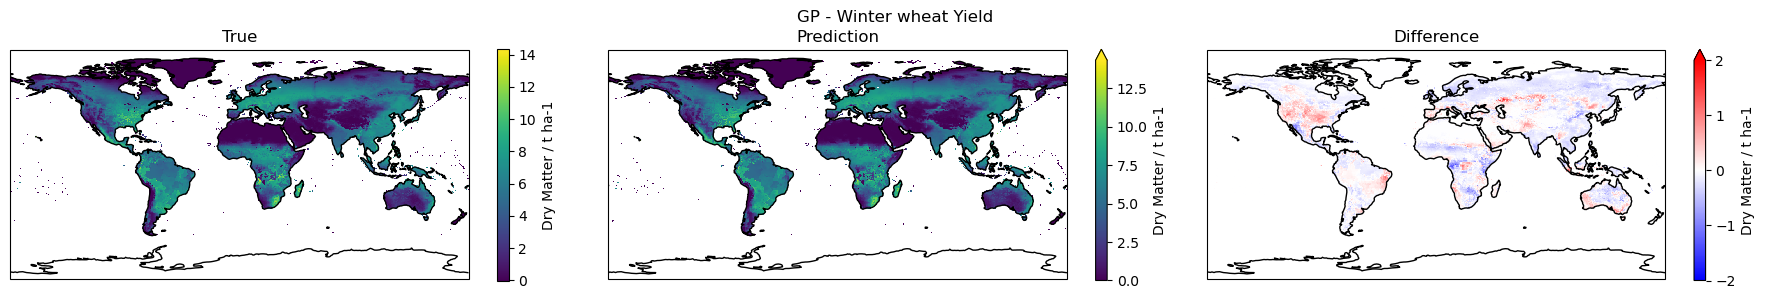

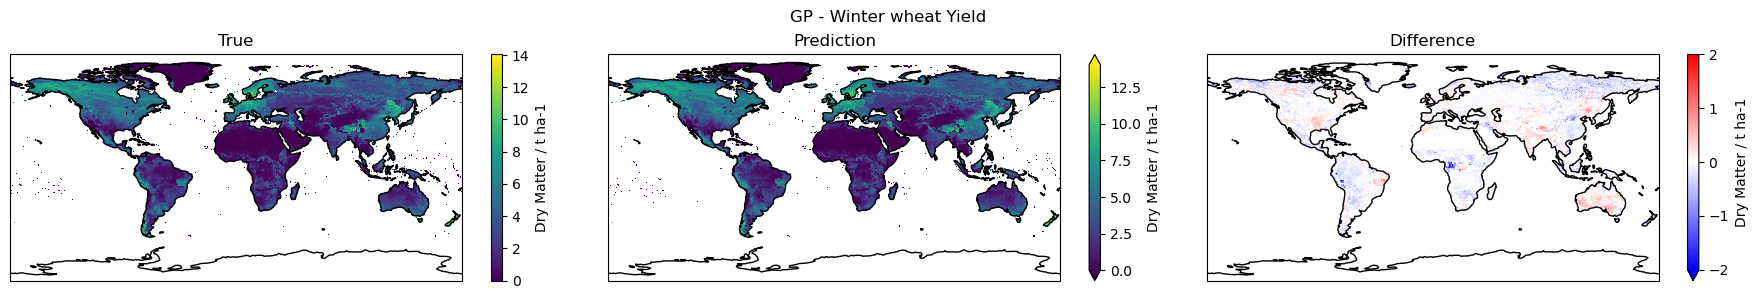

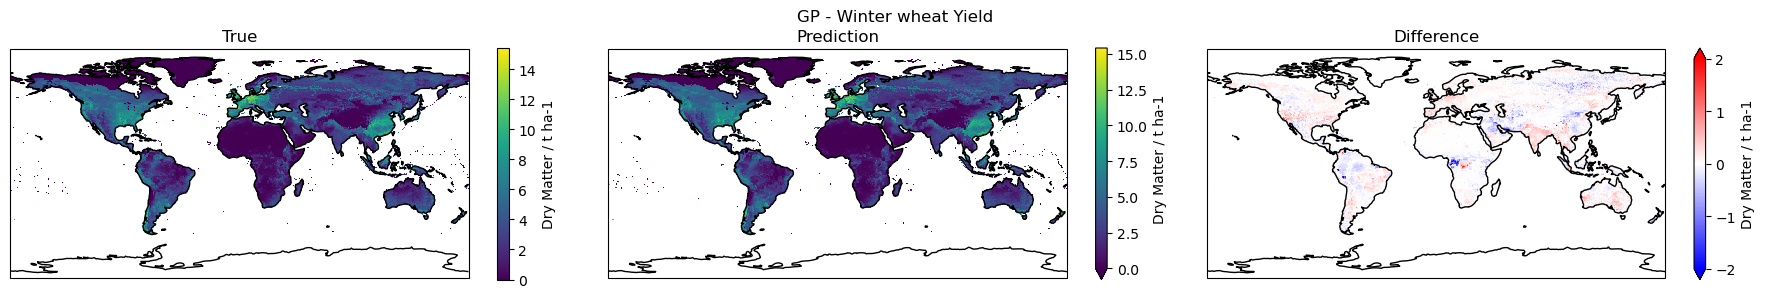

In [8]:
crop_name = {'mai': 'Maize', 'ri1': 'Rice (1st)', 'ri2': 'Rice (2nd)', 'soy': 'Soybean', 'swh': 'Spring wheat', 'wwh': 'Winter wheat'}

for crop in crops:
    yield_truth = Ytest[crop]
    posterior_yield_data = predictions[crop]['mean']

    
    truth_mean = yield_truth.sel(time=slice(2050,None)).mean('time')
    posterior_mean = posterior_yield_data.sel(time=slice(2050,None)).mean('time')
    difference = truth_mean - posterior_mean
    
    tmin, tmax = float(truth_mean.min()), float(truth_mean.max())
    pmin, pmax = float(posterior_mean.min()), float(posterior_mean.max())
    dmin, dmax = float(difference.min()), float(difference.max())
    
    
    buffer = 0.001
    vmin = tmin - buffer
    vmax = tmax + buffer
    
    
    abs_max_diff = max(abs(dmin), abs(dmax))
    diffnorm = colors.TwoSlopeNorm(vcenter=0., vmin=-2, vmax=2)
    
    # Plot
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(18,3))
    fig.suptitle(f'GP - {crop_name[k]} Yield')
    
    # 1) Truth
    ax1 = plt.subplot(131, projection=proj)
    truth_mean.plot(
        ax=ax1, cmap="viridis",
        vmin=vmin, vmax=vmax,
        cbar_kwargs={"label":"Dry Matter / t ha-1"}
    )
    ax1.coastlines()
    ax1.set_title('True')
    
    # 2) Posterior
    ax2 = plt.subplot(132, projection=proj)
    posterior_mean.plot(
        ax=ax2, cmap="viridis",
        vmin=vmin, vmax=vmax,
        cbar_kwargs={"label":"Dry Matter / t ha-1"}
    )
    ax2.coastlines()
    ax2.set_title('Prediction')
    
    # 3) Difference
    ax3 = plt.subplot(133, projection=proj)
    difference.plot(
        ax=ax3, cmap="bwr",
        norm=diffnorm,
        cbar_kwargs={"label":"Dry Matter / t ha-1"}
    )
    ax3.coastlines()
    ax3.set_title('Difference')
    
    plt.tight_layout()
    plt.show()
    
    #fig.savefig(f'./figs/GP-mai.png', transparent=True, dpi=300, format='png')